<a href="https://colab.research.google.com/github/Drews30/Projet-Quant-Actuariat/blob/main/ProjetDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:


# 1. Définition des caractéristiques de l'obligation
NOMINAL = 1000
TAUX_COUPON = 0.03 # 3%
MATURITE = 10

def calculer_prix(rendement_marche):
    i = rendement_marche / 100
    coupon_en_dollars = NOMINAL * TAUX_COUPON

    # 1. Calcul de la somme des coupons
    prix_coupons = 0
    for t in range(1, MATURITE + 1):
        prix_coupons += coupon_en_dollars / (1 + i)**t # Prix du coupon est divisé (1 + i)**t pour être actualisé

    # 2. Calcul du remboursement final actualisé
    nominal_actualise = NOMINAL / (1 + i)**MATURITE # PV du nominal qu'il nous sera redonné a Maturité

    # Étape finale : On combine les deux pour obtenir le prix total
    return prix_coupons + nominal_actualise

    #Utiliser la fonction pour comparaison avec le Yield d'une obligation et le Prix


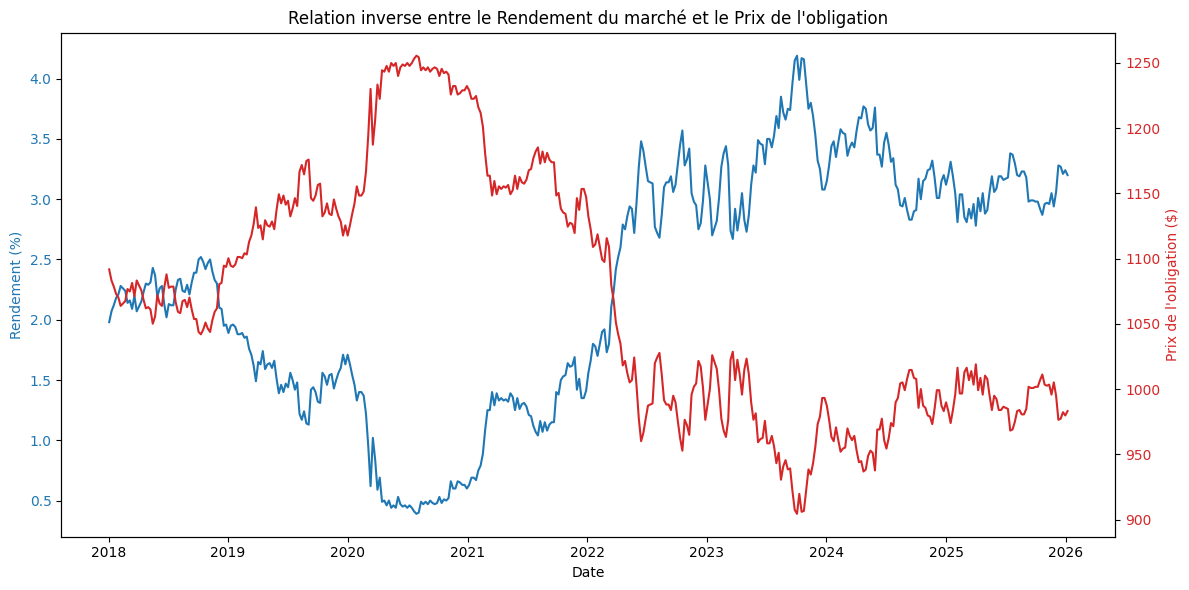

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Création de la df, lire et nettoyer le fichier entrant

df = pd.read_csv('lookup_10_years.csv', skiprows=11, on_bad_lines='skip')

df.columns = ['Date', 'Yield']

# 2. Format AAAA-MM-JJ précisément

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Yield'] = pd.to_numeric(df['Yield'], errors='coerce')

# 3. Nettoyage, éviter d'utiliser les monthly values

df=df.dropna().sort_values(by='Date')

df['Prix_Simule'] = df['Yield'].apply(calculer_prix)



# 1. Création de la figure et du premier axe (Rendement)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Courbe du Yield (Bleu)
ax1.plot(df['Date'], df['Yield'], color='tab:blue', label='Rendement (Yield)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Rendement (%)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# 2. Création du deuxième axe (Prix) qui partage le même axe X
ax2 = ax1.twinx() # Pertinent a retenir dans la librairie

# Courbe du Prix en rouge
ax2.plot(df['Date'], df['Prix_Simule'], color='tab:red', label='Prix Simulé')
ax2.set_ylabel('Prix de l\'obligation ($)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# 3. Titre
plt.title('Relation inverse entre le Rendement du marché et le Prix de l\'obligation')
fig.tight_layout()
plt.show()

In [16]:
# Ajout de features


# Ajout d'une colonne 'MM4'pour analyser la tendance du Yield sur les 4
# dernieres semaines

df['Yield_MM4'] = df['Yield'].rolling(window=4).mean()
# 3 premieres semaines 'NAN', car il n'y peut pas calculer 'MM4'

# Créer une colonne du passé récent pour prédire le futur proche

df['Yield_Lag'] = df['Yield'].shift(1)


df['Yield_Diff'] = df['Yield'] - df['Yield_Lag']
print(df.head())

df.dropna(inplace=True)

# Ajouter également des données macroéconomiques externes pour aider le
# modele a comprendre pourquoi les taux bougent



          Date  Yield  Prix_Simule  Yield_MM4  Yield_Lag  Yield_DP  Yield_Diff
418 2018-01-03   1.98  1091.718317        NaN        NaN       NaN         NaN
417 2018-01-10   2.07  1083.232911        NaN       1.98      0.09        0.09
416 2018-01-17   2.12  1078.552744        NaN       2.07      0.05        0.05
415 2018-01-24   2.18  1072.968306     2.0875       2.12      0.06        0.06
414 2018-01-31   2.21  1070.189012     2.1450       2.18      0.03        0.03
